# SmartCrop — Random Forest Training & Evaluation

Dataset: Crop_recommendation_4.csv
Model: Random Forest Classifier
Features: N, P, K, temperature, humidity, ph, rainfall
Target: 30 crop classes
Outputs: smartcrop_rf_model.pkl, smartcrop_label_encoder.pkl


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


## 1. Data Loading


In [28]:
df = pd.read_csv('Crop_recommendation_extended.csv')
df.head()
print(df.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            3000 non-null   float64
 1   P            3000 non-null   float64
 2   K            3000 non-null   float64
 3   temperature  3000 non-null   float64
 4   humidity     3000 non-null   float64
 5   ph           3000 non-null   float64
 6   rainfall     3000 non-null   float64
 7   label        3000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 187.6+ KB
None


## 2. Preprocessing


In [30]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
TARGET = 'label'

X = df[FEATURES]
y = df[TARGET]

le = LabelEncoder()
le.fit(y)


print("Features:", FEATURES)
print("Target:", TARGET)
print("Number of crop classes:", len(le.classes_))
print("Crop Classes:", list(le.classes_))

Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Target: label
Number of crop classes: 30
Crop Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'mustard', 'onion', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'sorghum', 'sugarcane', 'sunflower', 'tobacco', 'tomato', 'watermelon', 'wheat']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 3. Model Training


In [32]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 4. Evaluation


In [33]:
y_pred = rf.predict(X_test)


In [20]:
train_acc = rf.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)

print(f'Train Accuracy: {train_acc * 100:.2f}%')
print(f'Test  Accuracy: {test_acc  * 100:.2f}%')


Train Accuracy: 100.00%
Test  Accuracy: 98.33%


## Overfitting Check

Compares **Train Accuracy** vs **Test Accuracy**. 


In [21]:
train_acc_pct = rf.score(X_train, y_train) * 100
test_acc_pct = accuracy_score(y_test, y_pred) * 100
gap = train_acc_pct - test_acc_pct

print(f'Train Accuracy: {train_acc_pct:.2f}%')
print(f'Test  Accuracy: {test_acc_pct:.2f}%')
print(f'Gap           : {gap:.2f}%')

if gap < 2:
    print('Status: No overfitting - model generalizes well')
elif gap < 5:
    print('Status: Slight overfitting - acceptable')
else:
    print('Status: Overfitting detected - consider tuning max_depth or min_samples_leaf')

Train Accuracy: 100.00%
Test  Accuracy: 98.33%
Gap           : 1.67%
Status: No overfitting - model generalizes well


## Learning Curve

Shows how model performance changes with more training data. Helps diagnose **underfitting** (both curves low) vs **overfitting** (large gap between train and validation curves).



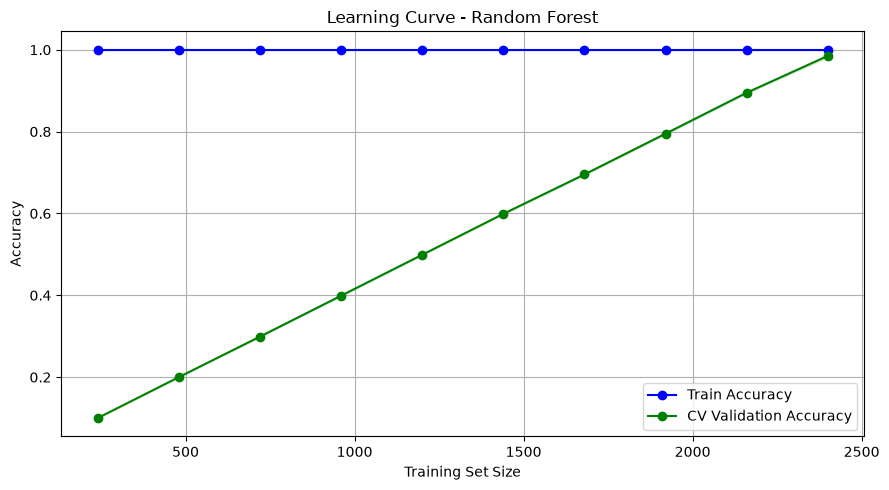

In [22]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    rf, X, y,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train Accuracy')
plt.plot(train_sizes, val_mean, 'o-', color='green', label='CV Validation Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='green')
plt.title('Learning Curve - Random Forest')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      1.00      1.00        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
     mustard       0.95      1.00      0.98        20
       onion       0.90    

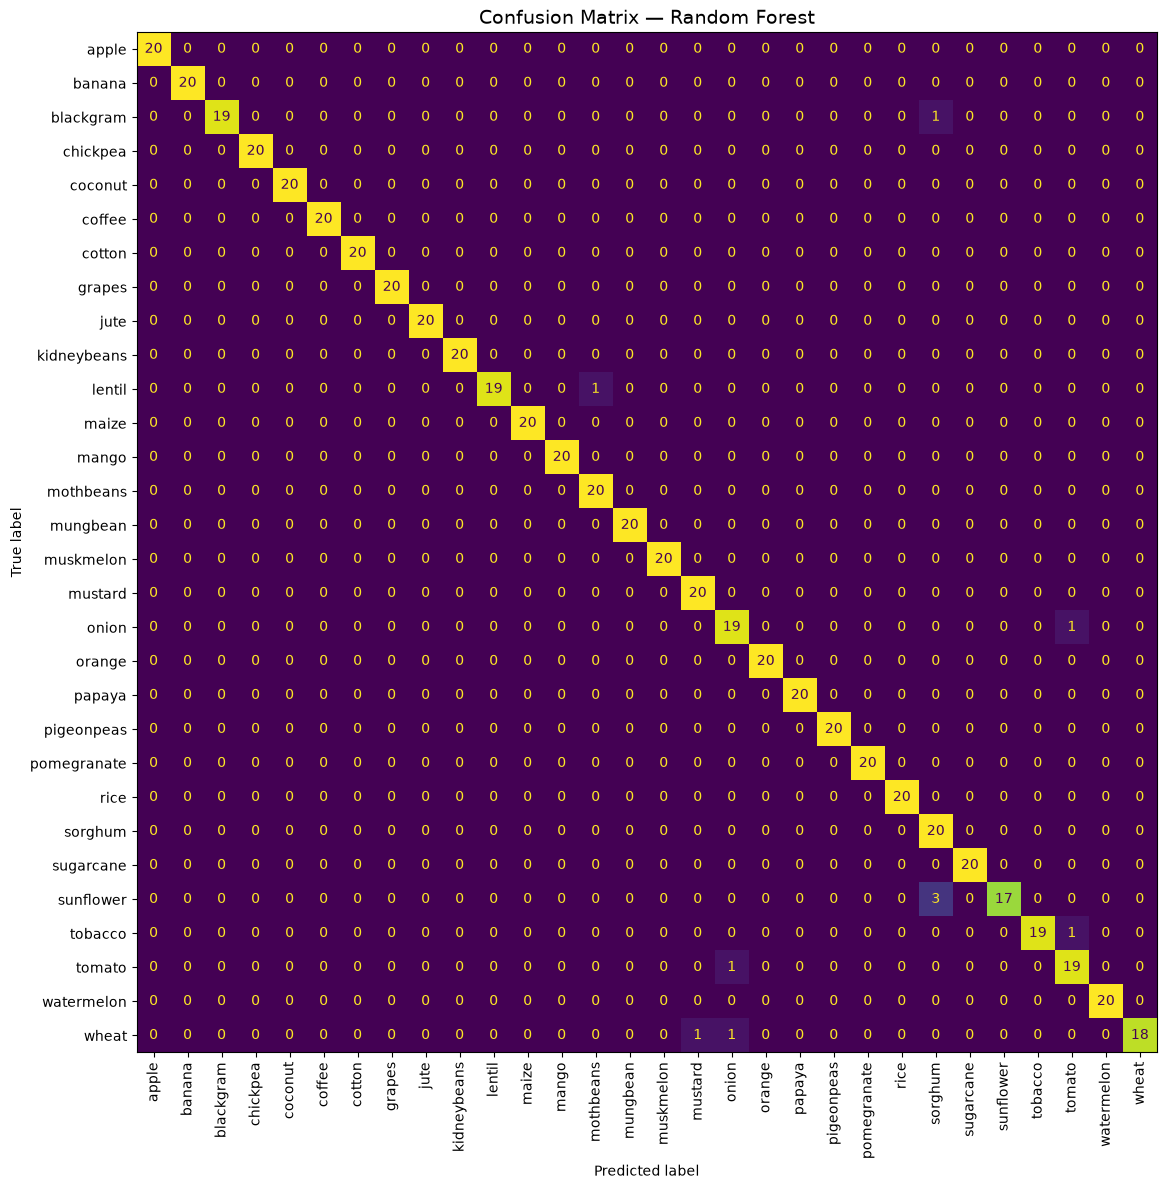

In [24]:
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
ax.set_title('Confusion Matrix — Random Forest', fontsize=14)
plt.tight_layout()
plt.show()


## CV Stability Check

Runs **5-Fold Stratified Cross-Validation** and checks the mean & standard deviation across folds.

- **High mean**   model performs well overall
- **Low std**  model is stable, not sensitive to which data it trains on


In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

cv_scores_pct = cv_scores * 100
print(f'CV Scores  : {[f"{s:.2f}" for s in cv_scores_pct]}')
print(f'Mean       : {cv_scores_pct.mean():.2f}%')
print(f'Std Dev    : {cv_scores_pct.std():.2f}%')

if cv_scores_pct.std() < 0.5:
    print('Stability: Very stable - low variance across folds')
elif cv_scores_pct.std() < 1.5:
    print('Stability: Stable - acceptable variance')
else:
    print('Stability: Unstable - high variance across folds')

CV Scores  : ['98.83', '98.83', '98.67', '98.67', '98.50']
Mean       : 98.70%
Std Dev    : 0.12%
Stability: Very stable - low variance across folds


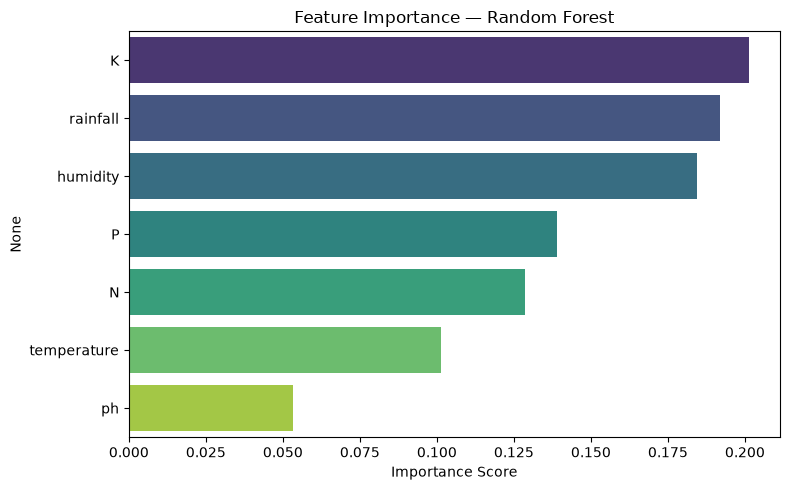

K              0.201321
rainfall       0.191971
humidity       0.184521
P              0.139113
N              0.128447
temperature    0.101320
ph             0.053307
dtype: float64


In [26]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importances)


## 5. Save Model


In [12]:
joblib.dump(rf, "smartcrop_rf_model.pkl")
joblib.dump(le, "smartcrop_label_encoder.pkl")


['smartcrop_label_encoder.pkl']

## 6. Inference Example


In [27]:
sample = pd.DataFrame([{
    'N': 119, 'P': 61, 'K': 45,
    'temperature': 17.0,
    'humidity': 60.0,
    'ph': 6.8,
    'rainfall': 49.0
}])

prediction = rf.predict(sample)[0]
proba = rf.predict_proba(sample)[0]

proba_df = pd.DataFrame({
    "crop": rf.classes_,
    "probability": proba
}).sort_values("probability", ascending=False).reset_index(drop=True)

confidence = proba.max()

print(f"Predicted Crop: {prediction}")
print(f"Confidence: {confidence * 100:.1f}%")
print()
print('{:<20s} {:>10s}'.format('Top 5 Crops', 'Confidence'))
print('-' * 31)
for i in range(5):
    row = proba_df.iloc[i]
    bar = '\u2588' * int(row['probability'] * 50)
    print('{:<20s} {:>7.2f}%  {}'.format(row['crop'], row['probability'] * 100, bar))


Predicted Crop: wheat
Confidence: 96.0%

Top 5 Crops          Confidence
-------------------------------
wheat                  96.00%  ████████████████████████████████████████████████
sunflower               3.00%  █
mustard                 1.00%  
banana                  0.00%  
watermelon              0.00%  
